In [1]:
import os
import pandas as pd
import numpy as np

In [2]:
os.listdir("../Nkhoma_data")

['Inpatient list Surgery',
 'Poor Patient Funds',
 'Data',
 'Volunteer Agreement',
 'laparoscopy_analysed.xlsx']

In [3]:
df = pd.read_excel("../Nkhoma_data/laparoscopy_analysed.xlsx")

/home/mat2m10/.pyenv/versions/3.12.9/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


In [4]:
# Assign placeholder IDs to rows missing a Hospital Number
mask = df["Hospital Number"].isna()
df.loc[mask, "Hospital Number"] = [f"UNKNOWN_{i+1}" for i in range(mask.sum())]

df = df.drop(columns=[c for c in df.columns if str(c).startswith("Unnamed")])
df = df.reset_index(drop=True)

# Reset index
df = df.dropna(subset=["Name"])

# Age

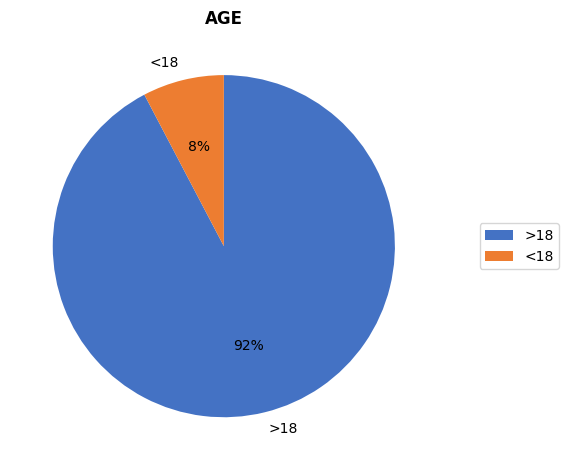

In [6]:
import matplotlib.pyplot as plt

age_groups = df["Age at surgery"].apply(lambda x: "<18" if x < 18 else ">18")
counts = age_groups.value_counts()

fig, ax = plt.subplots()
ax.pie(
    counts,
    labels=counts.index,
    autopct="%1.0f%%",
    colors=["#4472C4", "#ED7D31"],  # blue for >18, orange for <18
    startangle=90,
    counterclock=False
)
ax.set_title("AGE", fontweight="bold")
ax.legend(counts.index, loc="center right", bbox_to_anchor=(1.3, 0.5))
plt.tight_layout()
plt.show()

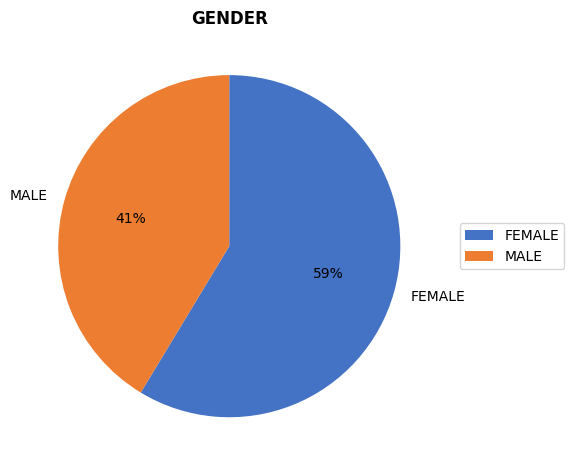

In [7]:
counts = df["Sex"].value_counts()

fig, ax = plt.subplots()
ax.pie(
    counts,
    labels=counts.index,
    autopct="%1.0f%%",
    colors=["#4472C4", "#ED7D31"],  # blue for MALE, orange for FEMALE
    startangle=90,
    counterclock=False
)
ax.set_title("GENDER", fontweight="bold")
ax.legend(counts.index, loc="center right", bbox_to_anchor=(1.3, 0.5))
plt.tight_layout()
plt.show()

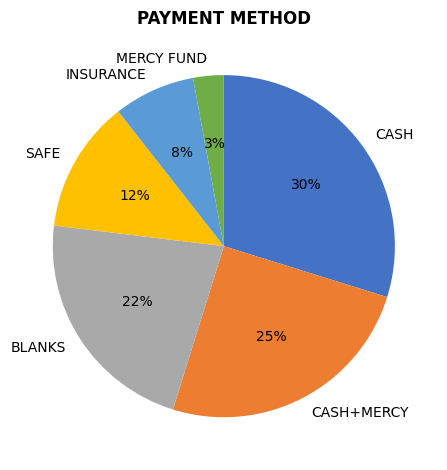

In [11]:
df["Payment Method (Scheme/ Cash)"] = df["Payment Method (Scheme/ Cash)"].str.strip().replace("", float("nan"))

counts = df["Payment Method (Scheme/ Cash)"].value_counts(dropna=False)
counts.index = counts.index.fillna("BLANKS")

colors = ["#4472C4", "#ED7D31", "#A9A9A9", "#FFC000", "#5B9BD5", "#70AD47"]

fig, ax = plt.subplots()
ax.pie(
    counts,
    labels=counts.index,
    autopct="%1.0f%%",
    colors=colors,
    startangle=90,
    counterclock=False
)
ax.set_title("PAYMENT METHOD", fontweight="bold")
plt.tight_layout()
plt.show()

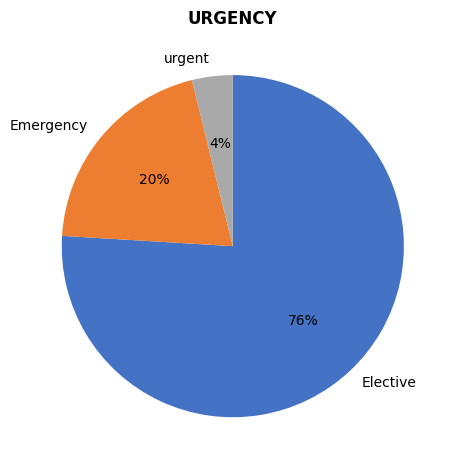

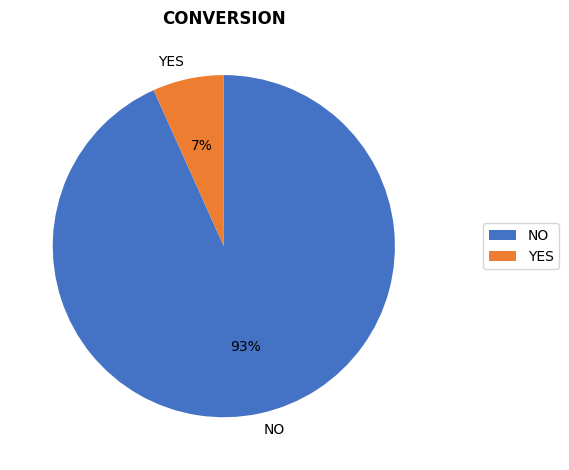

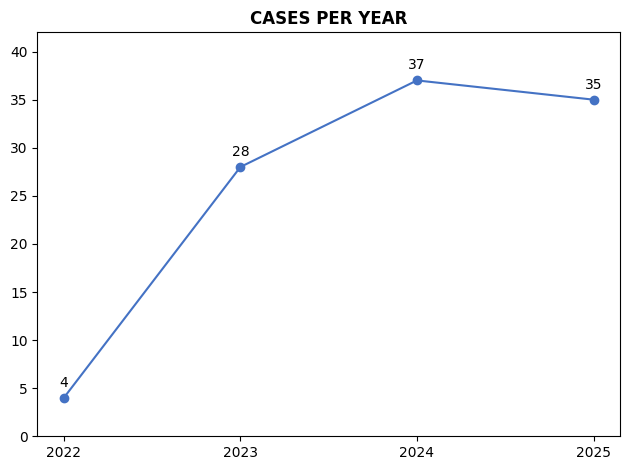

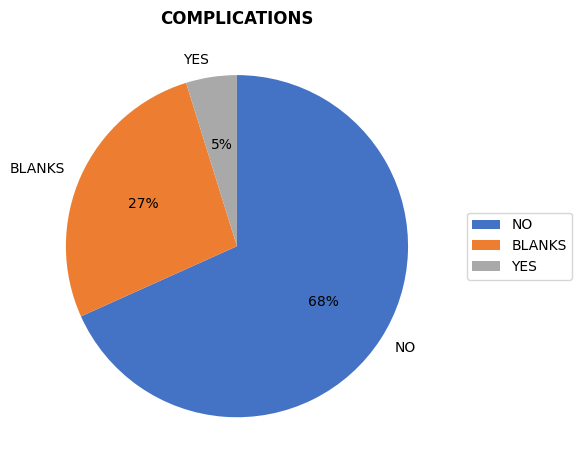

In [13]:
# --- URGENCY ---
counts_urgency = df["Urgency"].value_counts(dropna=False)
fig, ax = plt.subplots()
ax.pie(counts_urgency, labels=counts_urgency.index, autopct="%1.0f%%",
       colors=["#4472C4", "#ED7D31", "#A9A9A9"], startangle=90, counterclock=False)
ax.set_title("URGENCY", fontweight="bold")
plt.tight_layout()
plt.show()

# --- CONVERSION ---
counts_conv = df["Conversion"].str.strip().str.upper().value_counts(dropna=False)
counts_conv.index = counts_conv.index.fillna("BLANKS")
fig, ax = plt.subplots()
ax.pie(counts_conv, labels=counts_conv.index, autopct="%1.0f%%",
       colors=["#4472C4", "#ED7D31"], startangle=90, counterclock=False)
ax.set_title("CONVERSION", fontweight="bold")
ax.legend(counts_conv.index, loc="center right", bbox_to_anchor=(1.3, 0.5))
plt.tight_layout()
plt.show()

# --- CASES PER YEAR ---
df["Year"] = pd.to_datetime(df["Date of surgery"]).dt.year
cases_per_year = df["Year"].value_counts().sort_index()
fig, ax = plt.subplots()
ax.plot(cases_per_year.index, cases_per_year.values, marker="o", color="#4472C4")
for x, y in zip(cases_per_year.index, cases_per_year.values):
    ax.annotate(str(y), (x, y), textcoords="offset points", xytext=(0, 8), ha="center")
ax.set_title("CASES PER YEAR", fontweight="bold")
ax.set_xticks(cases_per_year.index)
ax.set_ylim(0, cases_per_year.max() + 5)
plt.tight_layout()
plt.show()

# --- COMPLICATIONS ---
counts_comp = df["Complication"].str.strip().str.upper().value_counts(dropna=False)
counts_comp.index = counts_comp.index.fillna("BLANKS")
fig, ax = plt.subplots()
ax.pie(counts_comp, labels=counts_comp.index, autopct="%1.0f%%",
       colors=["#4472C4", "#ED7D31", "#A9A9A9"], startangle=90, counterclock=False)
ax.set_title("COMPLICATIONS", fontweight="bold")
ax.legend(counts_comp.index, loc="center right", bbox_to_anchor=(1.3, 0.5))
plt.tight_layout()
plt.show()

In [15]:
def bin_teaching(val):
    if str(val).strip() == "<10":
        return "<10"
    val = float(val)
    if val <= 25: return "10-25"
    if val <= 50: return "26-50"
    if val <= 75: return "51-75"
    return "76-100"

df["Teaching % Group"] = df["Teaching %"].apply(bin_teaching)
counts = df["Teaching % Group"].value_counts().reindex(["<10", "10-25", "26-50", "51-75", "76-100"])

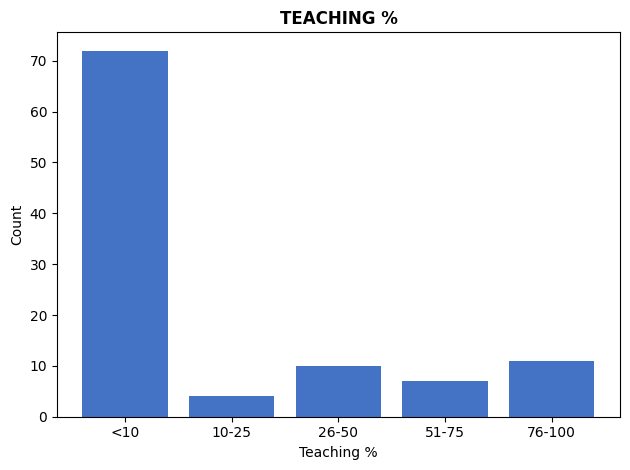

In [16]:
fig, ax = plt.subplots()
ax.bar(counts.index.astype(str), counts.values, color="#4472C4")
ax.set_title("TEACHING %", fontweight="bold")
ax.set_xlabel("Teaching %")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

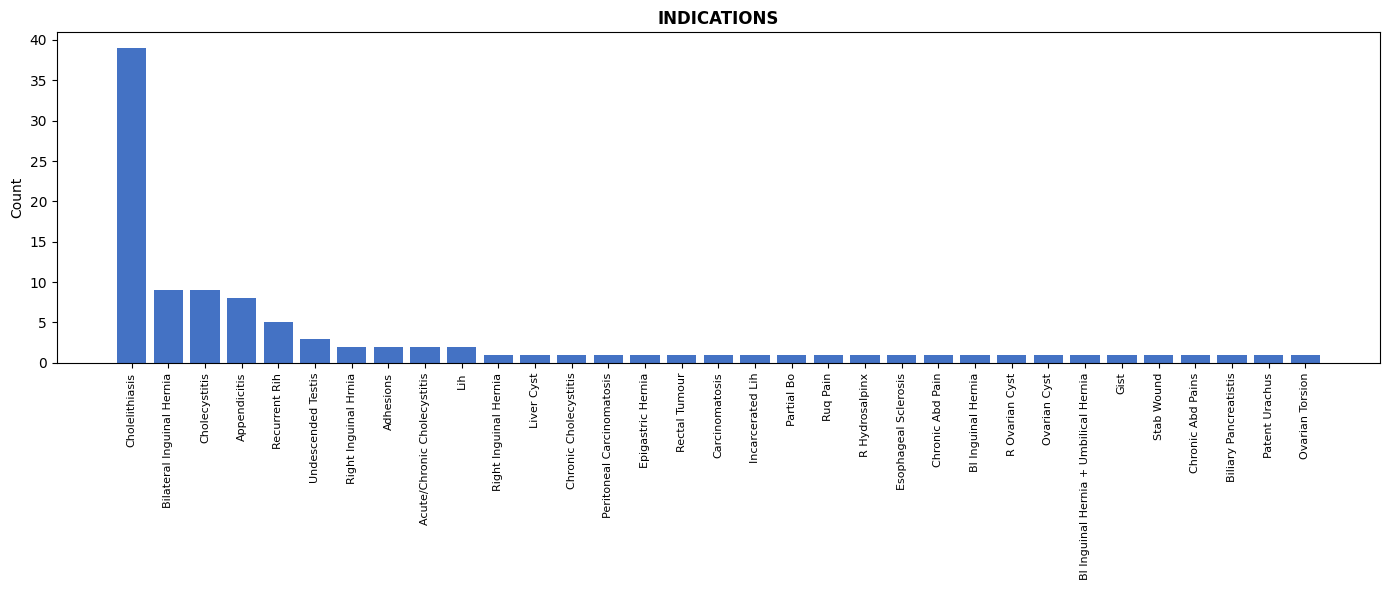

In [19]:
indication_map = {
    "Cholecystits": "Cholecystitis",
    "Lh": "Lih",
    "Rih": "Recurrent Rih",
    "Riqp": "Recurrent Rih",
    "Rlqp": "Recurrent Rih",
    # add more as needed
}

counts_ind = (df["Indication"]
              .str.strip()
              .str.lower()
              .str.title()
              .replace(indication_map)
              .value_counts()
              .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(counts_ind.index, counts_ind.values, color="#4472C4")
ax.set_title("INDICATIONS", fontweight="bold")
ax.set_ylabel("Count")
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.show()

In [20]:
df

,Hospital Number,Name,Village of residence,Sex,Age at surgery,Weight (kg),Ward,Previous abdominal surgery (Yes/No),Date of surgery,Type of Surgery,...,Teaching %,Amount of Gas Used (L),Conversion,Reason of conversion,Time of conversion (min. after incisicon),Complication,Complication (Clavien/Dindo),Complication description,Year,Teaching % Group
0,339284,Alex chitandale,malengachanza,MALE,28.0,NaN,SW,No,2022-10-20,AE,...,<10,50,No,NaN,NaN,no,NaN,NaN,2022,<10
1,UNKNOWN_1,Lifinet kapichi,mapiko,FEMALE,57.0,NaN,SW,No,2022-11-17,CHE,...,<10,37,No,NaN,NaN,NaN,NaN,NaN,2022,<10
2,341101,Annie Pheratu,area 23,FEMALE,38.0,NaN,SW,No,2022-11-24,CHE,...,<10,54,No,NaN,NaN,NaN,NaN,NaN,2022,<10
3,345144,chrissy nkanasi,kalolo,FEMALE,54.0,NaN,SW,No,2022-12-28,CHE,...,<10,270,No,NaN,NaN,NaN,NaN,NaN,2022,<10
4,344747,Brown Kapoloma,Kalosa,MALE,62.0,NaN,SW,No,2023-01-26,CHE 1 open prostatectomy,...,<10,242,No,NaN,NaN,No,NaN,NaN,2023,<10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,31248,Asiyatu Allan,dedza,FEMALE,41.0,,SW,No,2025-11-12,"laparoscopic cholecystectomy, chronic cholecys...",...,<10,163,no,,,No,,,2025,<10
100,,Marrium Lori,lilongwe,FEMALE,16.0,,SW,No,2025-11-18,"diagn. lsc. Urachus resection, 16yo. patent ur...",...,60,27,no,,,No,,,2025,51-75
101,31956,Grace Chipole,lilongwe,FEMALE,47.0,,PVT,No,2025-11-19,"laparoscopic cholecystectomy, sympt cholecysto...",...,50,43,no,,,No,,,2025,26-50
102,32499,Fatima Lack,lilongwe,FEMALE,32.0,,SW,No,2025-11-27,"laparoscopic r. adnexectomy, ovarian torsion",...,60,33,no,,,No,,,2025,51-75
